# **Telco Customer Churn**

---

exploration-prediction-project

---

## Project Overview
  The goal of this project is to explain why the customer might leave and reseach factors that influence the most and predict the behavior of customer.

  This is a supervised machine learning regression task based on the Telco Customer Churn dataset.

## Objectives


*   Perform exploratory data analysis (EDA)

*   Handle missing values and outliers

*   Engineer meaningful features
*   Create regresiion model (XGB, Linear Regression with Ridge and with Lasso)


*    Evaluate models performance
*    Research SHAP on the best one

*   Interpret vital features affecting customer churn



## Business understanding

Accurate distribution of customer churn can:


*  **Enables proactive intervention** – Instead of reacting when customers leave, you can spot at-risk users early and step in before they cancel.

* **Prevents unnecessary discounting** – When you know churn is rarely about price, you stop offering costly discounts and instead fix the real root cause.

* **Focuses efforts on high-value accounts** – You can prioritize retention work on customers who matter most to your revenue, rather than spreading efforts too thin.

* **Guides product development** – Hard data on why people leave gives your product team a clear, ROI-driven roadmap for what to build or fix next.

* **Optimizes marketing spend** – You can identify which acquisition channels bring in short-lived customers and shift budget toward those that yield loyal, long-term users.

* **Sharpens financial forecasting** – Knowing when churn is likely to happen allows you to predict revenue trends accurately and plan budgets, hiring, and sales targets with confidence.


The target variable (Yes-the customer has churned, No-otherwise ) is:
- `Churn`










In [45]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.inspection import permutation_importance
import shap
# Models
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import accuracy_score,confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 0

## Dataset Loading

In this section, the dataset is loaded.

In [46]:
df=pd.read_csv('Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Train-validation split:
Train-Validation Split for training and checking our future models.

In [47]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train,X_valid,y_train,y_valid=train_test_split(X,y, test_size=0.2,random_state=RANDOM_STATE)
df_train=pd.concat([X_train,y_train],axis=1)

## Preprocessing

In [48]:
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols.remove('customerID') 

preprocessor = ColumnTransformer([
    ('drop', 'drop', 'customerID'),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ]), cat_cols)
])
preprocessor.fit(X_train)
X_train_transf = preprocessor.transform(X_train)
le=LabelEncoder()
y_train_transf=le.fit_transform(y_train)
y_valid_transf=le.transform(y_valid)


## EDA
In the following cells the future inspection of training data is presented.

In [49]:
df_train.info()

<class 'pandas.DataFrame'>
Index: 5634 entries, 2920 to 2732
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   str    
 1   gender            5634 non-null   str    
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   str    
 4   Dependents        5634 non-null   str    
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   str    
 7   MultipleLines     5634 non-null   str    
 8   InternetService   5634 non-null   str    
 9   OnlineSecurity    5634 non-null   str    
 10  OnlineBackup      5634 non-null   str    
 11  DeviceProtection  5634 non-null   str    
 12  TechSupport       5634 non-null   str    
 13  StreamingTV       5634 non-null   str    
 14  StreamingMovies   5634 non-null   str    
 15  Contract          5634 non-null   str    
 16  PaperlessBilling  5634 non-null   str    
 17  PaymentM

In [50]:
df_train.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5634.000000
mean,0.162052,32.377352,64.834292
std,0.368531,24.573875,30.063617
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.712500
50%,0.000000,29.000000,70.400000
75%,0.000000,56.000000,89.887500
max,1.000000,72.000000,118.750000


In [51]:
missing=df.isnull().sum().sort_values(ascending=False)
missing.head()

customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64

This above shows that the training dataset doesn't contain any missing values. 

First of all, correlation between `tenure`(Number of months the customer has stayed with the company) and `Churn` is researched.


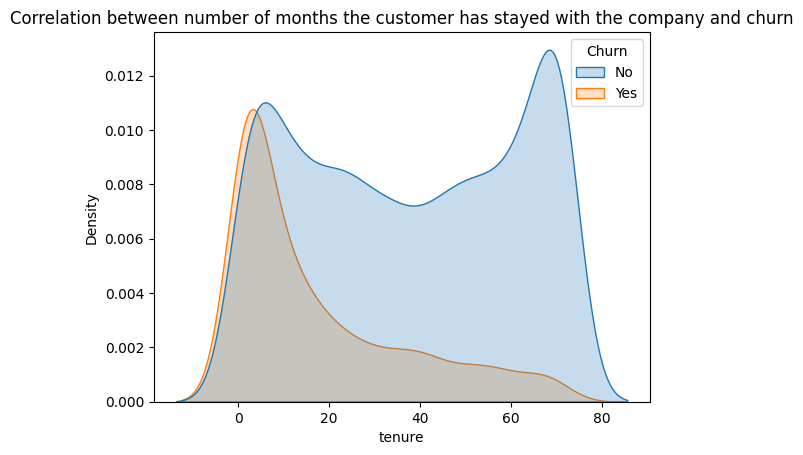

In [52]:
sns.kdeplot(data=df_train,x='tenure',hue='Churn', fill=True)
plt.title('Correlation between number of months the customer has stayed with the company and churn')
plt.show()

It shows that customers with quiet small tenure tend to leave whereas so-called 'experienced' users mostle stay with this company.

The next, correlation between `MonthlyCharges` and `Churn` is expected.

Text(0.5, 1.0, 'range of monthly fees')

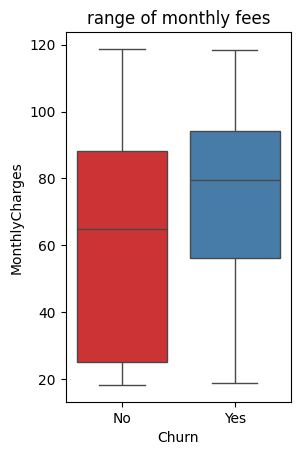

In [53]:
plt.subplot(1,2,2)
sns.boxplot(data=df_train,x='Churn',y='MonthlyCharges',palette='Set1')
plt.title('range of monthly fees')


It shows that people who has left tended to pay more.

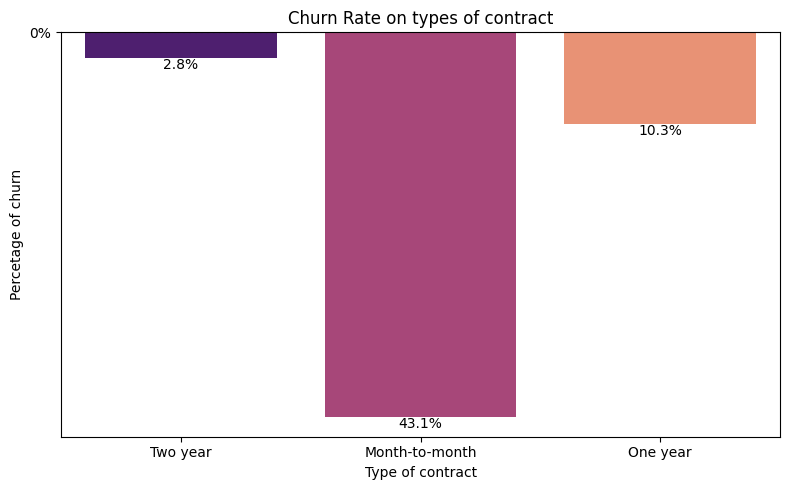

In [64]:
plt.figure(figsize=(8, 5))


ax = sns.barplot(
    data=df_train,
    x="Contract",
    y="Churn",
    errorbar=None,
    palette="magma",
)


vals = ax.get_yticks()
ax.set_yticklabels([f"{x*100:.0f}%" for x in vals])


for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f"{x*100:.1f}%", label_type="edge")

plt.title("Churn Rate on types of contract")
plt.xlabel("Type of contract")
plt.ylabel("Percetage of churn")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()



It shows that clients with month-to-month contract have higher churn rate, however clients with two year contract have the least one.

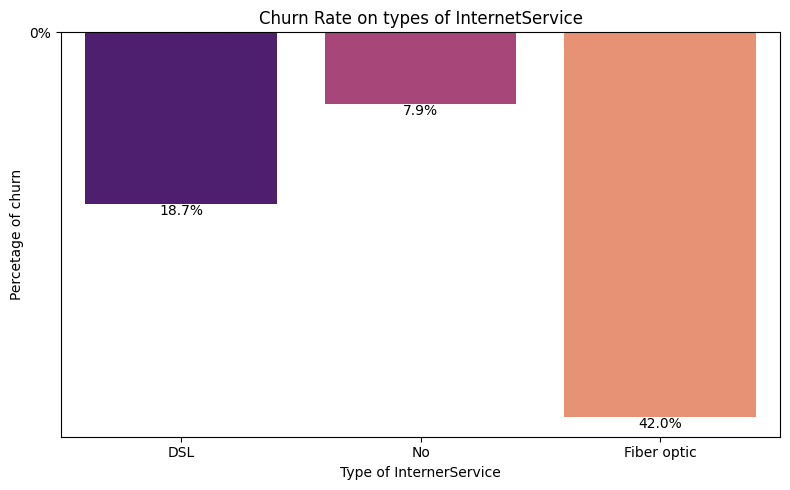

In [66]:
plt.figure(figsize=(8, 5))


ax = sns.barplot(
    data=df_train,
    x="InternetService",
    y="Churn",
    errorbar=None,
    palette="magma",
)


vals = ax.get_yticks()
ax.set_yticklabels([f"{x*100:.0f}%" for x in vals])


for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f"{x*100:.1f}%", label_type="edge")

plt.title("Churn Rate on types of InternetService")
plt.xlabel("Type of InternerService")
plt.ylabel("Percetage of churn")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Above, we can see that having no intrner service means less churn rate, but having fiber optic has more so-callled 'churn' clients.

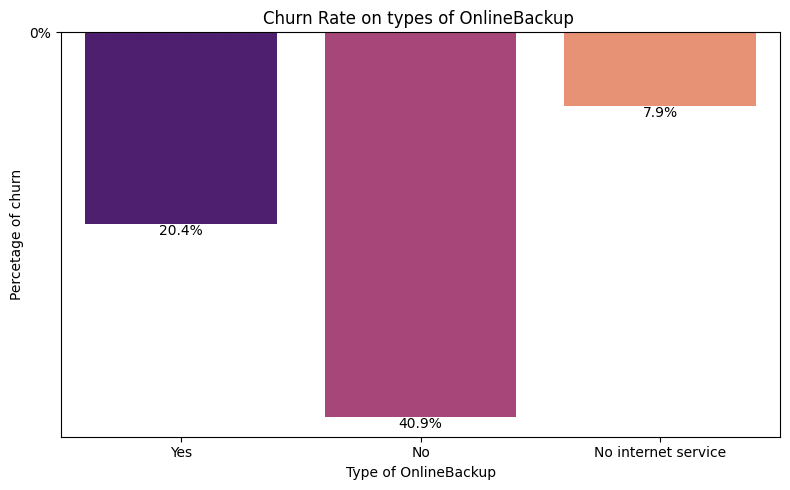

In [68]:
plt.figure(figsize=(8, 5))


ax = sns.barplot(
    data=df_train,
    x="OnlineBackup",
    y="Churn",
    errorbar=None,
    palette="magma",
)


vals = ax.get_yticks()
ax.set_yticklabels([f"{x*100:.0f}%" for x in vals])


for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f"{x*100:.1f}%", label_type="edge")

plt.title("Churn Rate on types of OnlineBackup ")
plt.xlabel("Type of OnlineBackup")
plt.ylabel("Percetage of churn")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Clients without online back up tend to churn much more often.

In [54]:

def imbalance_ratio(y_train):
    counts=np.bincount(y_train)
    return np.max(counts)/np.min(counts)
def minority_percentage(y_train):
    counts=np.bincount(y_train)
    return np.min(counts)/len(y_train) *100
print(f"Imbalance ratio {imbalance_ratio(y_train_transf)}")
print(f"Minority percentage {minority_percentage(y_train_transf)}")

Imbalance ratio 2.753497668221186
Minority percentage 26.641817536386224


The target value is imbalanced, so that in our case StandardScaler should be applied.

## Metrics
- **Accuracy** (proportion of all predictions)

    Accuracy = (TP + TN) / (TP + TN + FP + FN)
    P.S. the main disadvantage of this metrics: if the class is imbalanced, the model might categorize all the objects to the biggest group and do not categorize to the smallest at all, but metrisc would be pretty high.
- **Confusion matrix**

    (a table showing correct and incorrect predictions devided by TN (act: 0, pred: 0),FN(act: 1, pred: 0),FP(act: 0, pred: 1),TP(act: 1, pred: 1) )

- **Recall** (TP/TP+FN)

    This metrics is of utmost importance because it is vital not to skip people with disease, so the aim is to minimize False Negative.

- **Precision** (TP/TP+FP)

    This metrics shows the amount of true oositive of all positives.

- **F1 score**

    It shows the harmonic mean between recall and precision.

- **ROC-AUC**

    It indicates how good the model is at separating positive and negative labels.





## XGBClassifier

This is a machine learning model based on the XGBoost (Extreme Gradient Boosting) algorithm. It is an optimized distributed library for implementing gradient boosting, an ensemble learning method that combines the predictions of multiple weak models (usually decision trees) to create a stronger predictive model.

In [55]:
xgb_model= Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=50,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        random_state=RANDOM_STATE,
        
        use_label_encoder=False
    ))])



## LogisticRegression with Lasso L1

This is the application of the L1 regularization method to logistic regression, which involves adding a penalty in the form of the sum of the absolute values of the coefficients. This not only helps to reduce overfitting in the model, but also allows for feature selection by setting the coefficients of less significant variables to zero.





In [56]:
lasso_model= Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=RANDOM_STATE))])



## LogisticRegression with Ridge L2

This is a linear model regularization method (L2) that adds a penalty for the size of the coefficients to the loss function. It helps to combat multicollinearity and overfitting by stabilizing the coefficient estimates





In [57]:
ri_model= Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l2', C=1.0, random_state=RANDOM_STATE))])



## Comparison of models

In [58]:
models = {
    'Logistic (Lasso L1)': lasso_model,
    'Logistic (Ridge L2)': ri_model,
    'XGBoost (Base)': xgb_model
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train_transf)
    
    
    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)[:, 1]
    
    
    results.append({
        'Model': name,
       
        'ROC-AUC': roc_auc_score(y_valid_transf, y_proba),
        'Precision': precision_score(y_valid_transf, y_pred),
        'Recall': recall_score(y_valid_transf, y_pred),
        'Accuracy': accuracy_score(y_valid_transf, y_pred),
        'CV Score': cross_val_score(model, X_train, y_train_transf, cv=5, scoring='accuracy').mean()
    })



df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

              Model  ROC-AUC  Precision   Recall  Accuracy  CV Score
Logistic (Lasso L1) 0.824775   0.632653 0.505435  0.794180  0.802275
Logistic (Ridge L2) 0.825158   0.632653 0.505435  0.794180  0.804226
     XGBoost (Base) 0.827745   0.642857 0.391304  0.784244  0.799432


Accuracy is the highest in Lasso and Ridge;
ROC-AUC - Lasso;
Precision - Lasso and Ridge;;
Recall - Lasso and Ridge

It means that Logistic Regression with Lasso and with Ridge made much better results. Anyway, all models have optimistic cv score that means our model is not overfitted.

Lasso and Ridge models outperformed XGBoost because dataset likely has a strong linear structure and a high noise-to-signal ratio. Linear models naturally excel at capturing smooth, direct relationships, whereas tree-based algorithms like XGBoost try to approximate these lines using rigid "steps," leading to suboptimal splits. Furthermore, the dataset is relatively small, XGBoost tends to aggressively overfit the training data. Lasso (L1) and Ridge (L2) prevent this by restricting model complexity: Lasso effectively zeros out irrelevant, noisy features, while Ridge shrinks the weights of highly correlated variables. This mathematical constraint allows them to find stable, generalized patterns that perform significantly better on unseen test data.

## Permutation importance

It is used to measure the contribution of each feature to a machine learning model's predictive power. As mentioned above, one of the best performed model is Logistic with Ridge, so that these features will be shown using this model.

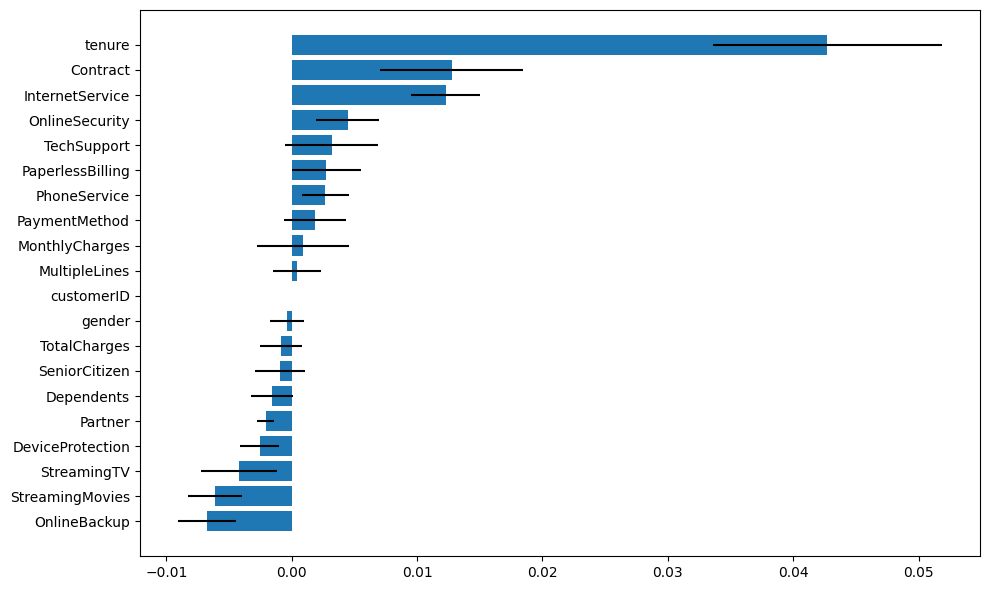

In [59]:
result=permutation_importance(ri_model,X_valid,y_valid_transf,n_repeats=10,random_state=RANDOM_STATE)
sorted_idx=result.importances_mean.argsort()
fig,ax=plt.subplots(figsize=(10,6))
ax.barh(range(X.shape[1]),result.importances_mean[sorted_idx],
        xerr=result.importances_std[sorted_idx], align='center')
ax.set_yticks(range(X.shape[1]))
ax.set_yticklabels(X_valid.columns[sorted_idx])
plt.tight_layout()
plt.show()

Depending on the plot shown above, the features like `tenure`, `Contract`, `InternetService` have a positive effect, making clients stay with this company. On the contrary, features like `OnlineBackup`,`StreamingMovies`,`StreamingTV` add noise to the result of our model.

## SHAP

It is a method for interpreting machine learning model predictions based on game theory and the concept of Shapley values. It allows you to understand how each feature (input characteristic) contributes to the final prediction of the model, providing both local and global interpretability.

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


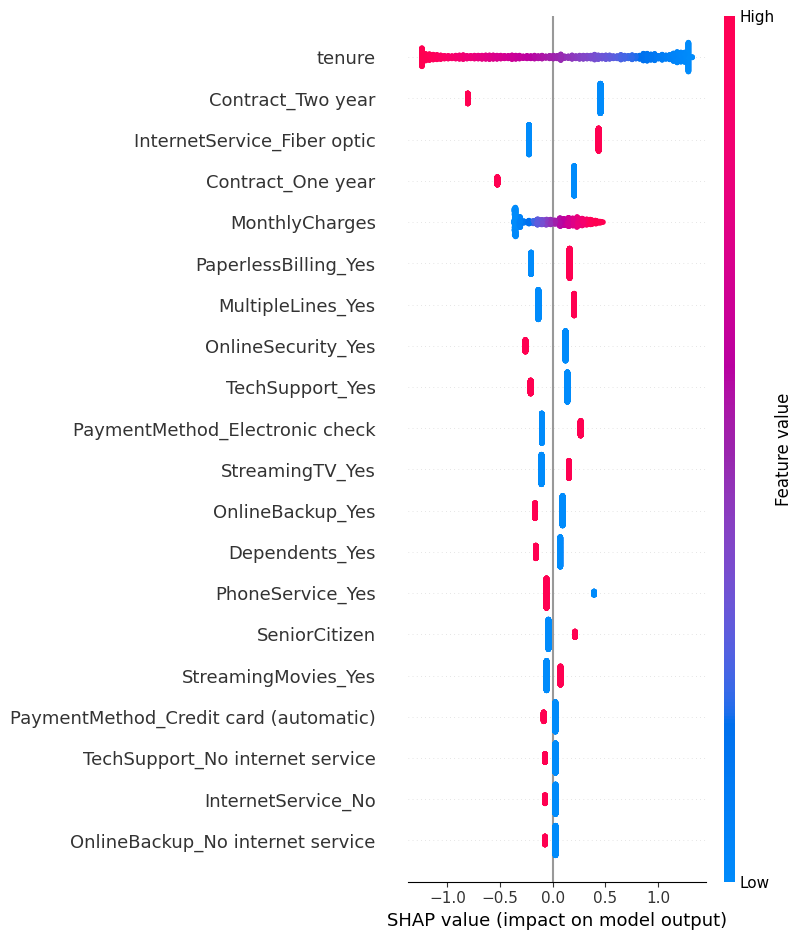

In [76]:
classifier = ri_model.named_steps['classifier']
X_valid_transf = preprocessor.transform(X_valid)

raw_features = preprocessor.get_feature_names_out()
clean_features = [col.replace('num__', '').replace('cat__', '') for col in raw_features]


X_valid_df = pd.DataFrame(X_valid_transf, columns=clean_features)
X_train_transf_df = pd.DataFrame(X_train_transf, columns=clean_features)


explainer = shap.LinearExplainer(classifier, X_train_transf_df)
shap_values = explainer(X_valid_df)

shap.summary_plot(shap_values, X_valid_df)


The most important features are tenure (the higher tenure, the less probability of tenure), two-year contract (availability of 2-year contract decreases the risk of churn), interner service with fiber optic (using fiber optic increases the risk of churn)

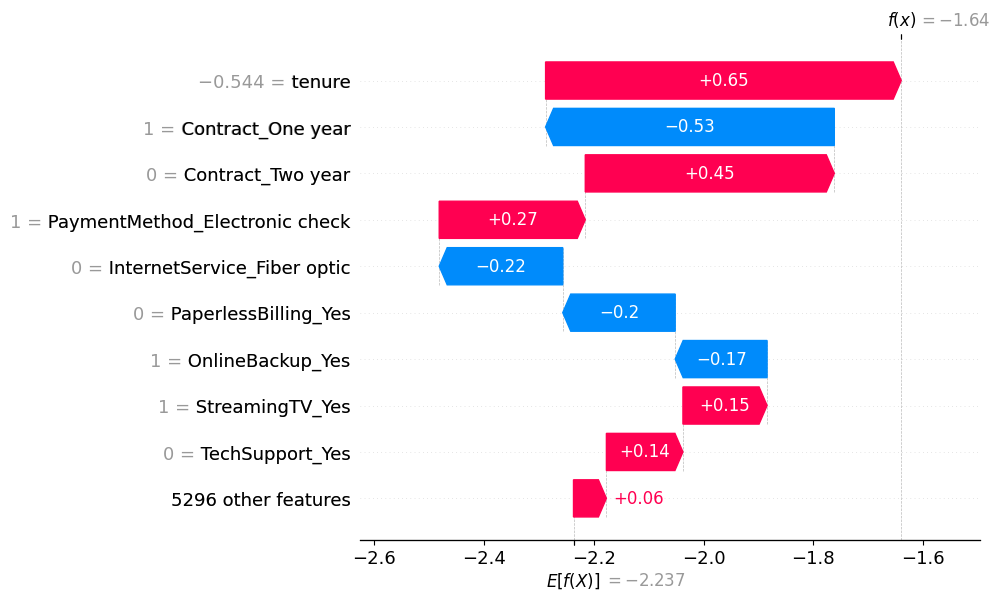

In [83]:
shap.plots.waterfall(shap_values[0])

Above, an example of a client with NO-churn. Conclusions can be made about this particular client: lower than the mean tenure, no two-year contract, electronic check payment method, presence of streaming TV, no tech support lead to increase of churn. However, what lead to NO-churn is presence of 1-year contract,no fiber optic internet service, no paperless billing, online backup.

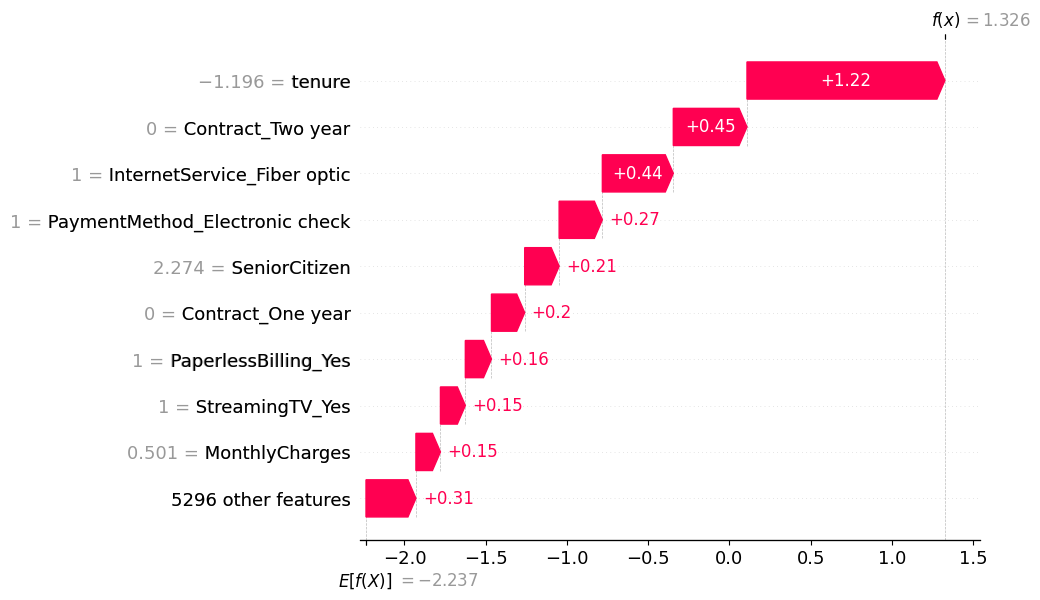

In [87]:
shap.plots.waterfall(shap_values[5])

Above, a prime example of a client with YES-churn. Conclusions can be made about this particular client: lower than the mean tenure, no two-year contract,fiber optic internet service, electronic check payment method, being senior citizen,presence of streaming TV, higher than the mean monthly charges lead to YES-churn.


## Conclusion

The objective of this project was to analyze factors influencing clients' leave and develop machine learning models capable of predicting whether the client will churn or not (`Churn`) based on their services available and individual features.

During the exploratory data analysis and feature engineering stages, key pipelines were constructed to handle complex raw features efficiently. After applying advanced preprocessing via a `ColumnTransformer`—including median imputation for missing numeric data, standard scaling, label encoding (for y_train/valid) and one-hot encoding for categorical variables with the dropping of first categories to avoid multicollinearity—the dataset was fully optimized for model training.

Two machine learning models were trained and evaluated: **XGBClassifier**,**LogisticRegression with LASSO L1**, **LogisticRegression with RIDGE L2**. Model performance was assessed using **Precision, Recall, F1-Score, Accuracy** on the validation dataset, supported by a 5-fold cross-validation process **CV score** for the ensemble method. 

The results showed that all models delivered competitive and closely matched performance. However, the best result was made by 
**LogisticRegression with RIDGE L2** with ~79,42% accuracy and ~80,42% cross-validation score (it gives us confidence to be sure that our model is neither overfitting nor underfitting). 

For that reason, Permutation importance and SHAP analyses were permormed on LogisticRegression with RIDGE. Considering PI results, the main factors which have the ggreates impact on the model are `tenure`,`contract`,`internet service`. Also, using SHAP, the conclusion were made: 
* the higher tenure, the less probability of tenure (the reason for that might well be that the company is quite reliable and such clients have enough of service), 
* availability of 2-year contract decreases the risk of churn (the reason for that might well be that such clients have been using that company for a long time and no problem about searching for some other provider in the short distance)
* using fiber optic increases the risk of churn (the reason for that might well be that the Internet connection and quality using such technology is quite poor). Next, using SHAP the examples of YES- and NO- churn confirmed the stated above reasons.


**Future improvements could include:**
1. **XGB Boost hyperparameters** (adjusting `n_estimators`, `max_depth`, and `min_samples_split`) to break past the current performance ceiling.
2. **Adjusting the classification threshold** away from the standard 50% mark depending on whether a shift toward higher precision or higher recall is desired.
3. **Advanced feature engineering**, such as creating interaction terms between passenger age and their luxury spending rates.
4. **Implementing cost-sensitive learning** to mathematically weigh and control the specific trade-off penalty between False Positives and False Negatives.

Also, some recommendations for the business that might lead to NO-churn clients: 
* value clients with high tenure and also try to make people stay longer by applying bonuses
* practice of 2-year contract (at least year one) will make client get acquanted with your company 
* advise clients to change fiber optic to some other alternatives
* apply more and more online back-up


Overall, this project demonstrated the complete machine learning workflow for binary classification, including automated feature extraction, robust pipeline preprocessing, model training, and comparative evaluation. The results highlight that **LogisticRegression with RIDGE L2 is the most appropriate model for this analytical task**, prioritizing the exact and definitive identification of feature combinations that drive clients churn.
